# Maybank (1155.KL) Trading Signal Prediction with XGBoost
### Using FBM KLCI (Top 30 Malaysian companies index, which includes Maybank) as a market-context feature

This notebook builds a **3-class classifier** that predicts a next-day trading action for **Maybank (1155.KL)**:

| Class | Meaning | Trigger |
|---|---|---|
| `0` | **Hold** | next-day return stays inside a neutral band |
| `1` | **Buy**  | next-day return is meaningfully positive |
| `2` | **Sell** | next-day return is meaningfully negative |

using:
- Maybank's own OHLCV-derived technical features (momentum, trend, volatility, volume)
- FBM KLCI (`^KLSE`) index-derived features, since Maybank is a large constituent of the index and broad market direction often leads/confirms individual stock moves

**Structure of this notebook:**
1. Data Cleaning
2. Time-Series Data Split (Train / Valid / Test = 7:2:1)
3. Feature Engineering
4. XGBoost Hyperparameter Tuning (with early stopping)
5. Baseline Comparison
6. Full Model Evaluation Results
7. Test (Production) Score
8. Mock Trading Simulation

> **Note:** This notebook downloads live data via `yfinance`, so it must be run in an environment with internet access (e.g. locally or on Google Colab).

## 0. Setup & Installs

Install/import all required libraries. `ta` is used for technical-analysis indicators, `xgboost` for the classifier.

In [27]:
import warnings
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ta
import optuna
import yfinance as yf


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [28]:
# --- Config ---
MAYBANK_TICKER = "1155.KL"  # Maybank on Bursa Malaysia
KLCI_TICKER = "^KLSE"  # FTSE Bursa Malaysia KLCI (top 30 companies, incl. Maybank)

START_DATE = "2010-01-01"
END_DATE = None  # None = up to today

print(f"Maybank ticker : {MAYBANK_TICKER}")
print(f"FBM KLCI ticker: {KLCI_TICKER}")

Maybank ticker : 1155.KL
FBM KLCI ticker: ^KLSE


## Download Raw Data

We pull daily OHLCV data for both Maybank and the FBM KLCI index. The KLCI series will later be merged in as *contextual/market* features — Maybank is one of the index's largest constituents, so the index's own momentum/trend can carry predictive signal for the individual stock.

In [29]:
maybank_raw = yf.download(
    MAYBANK_TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False
)
klci_raw = yf.download(
    KLCI_TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False
)

# yfinance sometimes returns MultiIndex columns for a single ticker - flatten if needed
if isinstance(maybank_raw.columns, pd.MultiIndex):
    maybank_raw.columns = maybank_raw.columns.get_level_values(0)
if isinstance(klci_raw.columns, pd.MultiIndex):
    klci_raw.columns = klci_raw.columns.get_level_values(0)

print("Maybank shape:", maybank_raw.shape)
print("KLCI shape   :", klci_raw.shape)
maybank_raw.tail()

Maybank shape: (4113, 6)
KLCI shape   : (4089, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-09-07,10.58,10.58,10.64,10.56,10.56,11027500
2026-09-08,10.54,10.54,10.60,10.54,10.58,8389200
2026-09-09,10.46,10.46,10.56,10.46,10.56,17425300
2026-09-10,10.46,10.46,10.54,10.46,10.50,8373300
2026-09-11,10.38,10.38,10.48,10.38,10.48,11956900


## 1. Data Cleaning

Requirement: **drop rows that have null values in OHLCV (Open, High, Low, Close, Volume)**, for both Maybank and the FBM KLCI series, before any feature engineering happens. We also align both series on the trading calendar (inner join on date), since holidays can differ slightly and we need matched dates when merging KLCI features onto Maybank rows.

In [30]:
def clean_ohlcv(df, name):
    ohlcv_cols = ["Open", "High", "Low", "Close", "Volume"]
    before = len(df)
    df = df.copy()

    # Keep only rows where all OHLCV columns are present and non-null
    df = df.dropna(subset=ohlcv_cols)

    # Defensive: drop any rows where volume is 0 (non-trading / bad data) which can break pct_change features
    df = df[df["Volume"] > 0]

    after = len(df)
    print(
        f"[{name}] Dropped {before - after} rows with null/invalid OHLCV out of {before} total rows."
    )
    return df


maybank_clean = clean_ohlcv(maybank_raw, "Maybank")
klci_clean = clean_ohlcv(klci_raw, "FBM KLCI")

# Align both series on shared trading dates (inner join) so KLCI features line up 1-to-1 with Maybank rows
common_dates = maybank_clean.index.intersection(klci_clean.index)
maybank_clean = maybank_clean.loc[common_dates].sort_index()
klci_clean = klci_clean.loc[common_dates].sort_index()

print(f"\nAligned shape (both series): {maybank_clean.shape}")
assert maybank_clean.isna().sum().sum() == 0, "Nulls remain in Maybank OHLCV!"
assert klci_clean.isna().sum().sum() == 0, "Nulls remain in KLCI OHLCV!"
print("No nulls remain in either OHLCV dataset. ✅")

[Maybank] Dropped 32 rows with null/invalid OHLCV out of 4113 total rows.
[FBM KLCI] Dropped 16 rows with null/invalid OHLCV out of 4089 total rows.

Aligned shape (both series): (4066, 6)
No nulls remain in either OHLCV dataset. ✅


## 2. Time-Series Data Split (Train : Valid : Test = 7 : 2 : 1)

Because this is time-series data, we **never shuffle**. We split chronologically:

- **Train (70%)** — used to fit the model
- **Valid (20%)** — used for hyperparameter tuning / early stopping
- **Test (10%)** — held out completely, touched only once at the end, to simulate genuine "production" performance on unseen future data

We compute the split **cutoff dates** here on the cleaned, aligned date index. The actual feature matrix (built in Section 3) will be sliced using these same cutoff dates, so there is no leakage of future information into earlier splits (e.g. no rolling-window feature is allowed to peek across the boundary in a way that uses test labels).

In [31]:
n = len(maybank_clean)
train_end_idx = int(n * 0.6)
valid_end_idx = int(n * 0.8)  # 0.7 + 0.2

train_dates = maybank_clean.index[:train_end_idx]
valid_dates = maybank_clean.index[train_end_idx:valid_end_idx]
test_dates = maybank_clean.index[valid_end_idx:]

print(f"Total rows : {n}")
print(
    f"Train      : {len(train_dates):>5} rows  ({train_dates.min().date()} -> {train_dates.max().date()})"
)
print(
    f"Valid      : {len(valid_dates):>5} rows  ({valid_dates.min().date()} -> {valid_dates.max().date()})"
)
print(
    f"Test (prod): {len(test_dates):>5} rows  ({test_dates.min().date()} -> {test_dates.max().date()})"
)
print(
    f"\nRatio check -> train: {len(train_dates) / n:.2%}, valid: {len(valid_dates) / n:.2%}, test: {len(test_dates) / n:.2%}"
)

Total rows : 4066
Train      :  2439 rows  (2010-01-04 -> 2020-01-03)
Valid      :   813 rows  (2020-01-06 -> 2023-05-16)
Test (prod):   814 rows  (2023-05-17 -> 2026-09-11)

Ratio check -> train: 59.99%, valid: 20.00%, test: 20.02%


## 3. Feature Engineering

We build two feature blocks:

1. **Maybank technical features** — momentum (RSI, MACD), trend/moving-average ratios, ADX, rolling return mean/std, and volume features (exactly as specified).
2. **FBM KLCI market-context features** — the *same* style of technical features computed on the index itself, prefixed `klci_`, then merged onto the Maybank rows by date. Since Maybank is a top constituent of the KLCI, the index's own trend/momentum acts as a broad market signal that can help/confirm Maybank's own direction.

All rolling/indicator calculations are done on the **full continuous price history** (not per-split) since these are standard causal (backward-looking only) technical indicators — each value at time *t* only uses data up to and including *t*, so there is no leakage across the train/valid/test boundaries we defined above.

In [32]:
def build_technical_features(df, prefix=""):
    """Builds the requested technical-analysis feature set on a single OHLCV dataframe.
    Returns a DataFrame of features only (same index as df), optionally prefixed
    (used to distinguish KLCI features from Maybank features after merging).
    """
    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    feat = pd.DataFrame(index=df.index)

    # --- Momentum ---
    feat["rsi_14"] = ta.momentum.RSIIndicator(close, window=14).rsi()

    macd = ta.trend.MACD(close)
    feat["macd"] = macd.macd()
    feat["macd_signal"] = macd.macd_signal()
    feat["macd_diff"] = macd.macd_diff()

    # --- Trend / moving averages (ratios, not raw price, for stationarity) ---
    sma_5 = ta.trend.SMAIndicator(close, window=5).sma_indicator()
    sma_10 = ta.trend.SMAIndicator(close, window=10).sma_indicator()
    sma_20 = ta.trend.SMAIndicator(close, window=20).sma_indicator()
    sma_50 = ta.trend.SMAIndicator(close, window=50).sma_indicator()

    feat["price_to_sma5"] = close / sma_5 - 1
    feat["price_to_sma10"] = close / sma_10 - 1
    feat["price_to_sma20"] = close / sma_20 - 1
    feat["price_to_sma50"] = close / sma_50 - 1
    feat["sma20_to_sma50"] = sma_20 / sma_50 - 1

    feat["adx_14"] = ta.trend.ADXIndicator(high, low, close, window=14).adx()

    ret = close.pct_change()
    for window in [5, 10, 20]:
        feat[f"ret_mean_{window}"] = ret.rolling(window).mean()
        feat[f"ret_std_{window}"] = ret.rolling(window).std()

    # --- Volume ---
    feat["volume_change"] = volume.pct_change()
    feat["volume_sma_ratio"] = volume / volume.rolling(20).mean() - 1

    if prefix:
        feat = feat.add_prefix(prefix)

    return feat


maybank_feat = build_technical_features(maybank_clean)  # e.g. rsi_14, macd, ...
klci_feat = build_technical_features(
    klci_clean, prefix="klci_"
)  # e.g. klci_rsi_14, klci_macd, ...

print("Maybank feature columns:", list(maybank_feat.columns))
print("\nKLCI feature columns   :", list(klci_feat.columns))

Maybank feature columns: ['rsi_14', 'macd', 'macd_signal', 'macd_diff', 'price_to_sma5', 'price_to_sma10', 'price_to_sma20', 'price_to_sma50', 'sma20_to_sma50', 'adx_14', 'ret_mean_5', 'ret_std_5', 'ret_mean_10', 'ret_std_10', 'ret_mean_20', 'ret_std_20', 'volume_change', 'volume_sma_ratio']

KLCI feature columns   : ['klci_rsi_14', 'klci_macd', 'klci_macd_signal', 'klci_macd_diff', 'klci_price_to_sma5', 'klci_price_to_sma10', 'klci_price_to_sma20', 'klci_price_to_sma50', 'klci_sma20_to_sma50', 'klci_adx_14', 'klci_ret_mean_5', 'klci_ret_std_5', 'klci_ret_mean_10', 'klci_ret_std_10', 'klci_ret_mean_20', 'klci_ret_std_20', 'klci_volume_change', 'klci_volume_sma_ratio']


In [33]:
# Merge KLCI (market-context) features onto Maybank rows by date, plus a couple of direct
# Maybank-vs-market relative features, which is exactly where the KLCI adds value: relative strength.
features = maybank_feat.join(klci_feat, how="inner")

# Relative-strength features: how Maybank's own return compares to the broader market's return
maybank_ret = maybank_clean["Close"].pct_change()
klci_ret = klci_clean["Close"].pct_change()
features["maybank_vs_klci_ret_1d"] = maybank_ret - klci_ret
features["maybank_vs_klci_ret_5d"] = (
    maybank_ret.rolling(5).mean() - klci_ret.rolling(5).mean()
)
features["maybank_vs_klci_rsi_diff"] = maybank_feat["rsi_14"] - klci_feat["klci_rsi_14"]

print("Final combined feature matrix shape (pre-NaN-drop):", features.shape)
features.tail()

Final combined feature matrix shape (pre-NaN-drop): (4066, 39)


,rsi_14,macd,macd_signal,macd_diff,price_to_sma5,price_to_sma10,price_to_sma20,price_to_sma50,sma20_to_sma50,adx_14,ret_mean_5,ret_std_5,ret_mean_10,ret_std_10,ret_mean_20,ret_std_20,volume_change,volume_sma_ratio,klci_rsi_14,klci_macd,klci_macd_signal,klci_macd_diff,klci_price_to_sma5,klci_price_to_sma10,klci_price_to_sma20,klci_price_to_sma50,klci_sma20_to_sma50,klci_adx_14,klci_ret_mean_5,klci_ret_std_5,klci_ret_mean_10,klci_ret_std_10,klci_ret_mean_20,klci_ret_std_20,klci_volume_change,klci_volume_sma_ratio,maybank_vs_klci_ret_1d,maybank_vs_klci_ret_5d,maybank_vs_klci_rsi_diff
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-09-07,43.605405,-0.056896,-0.061686,0.004791,0.000378,-0.002451,-0.002734,-0.018116,-0.015424,10.287220,-0.001866,0.005786,0.000026,0.007584,-0.001009,0.006406,-0.056059,-0.465794,46.129882,-1.737917,2.197664,-3.935582,0.003118,-0.005126,-0.007927,0.000811,0.008808,23.731369,-0.001261,0.008322,-0.001248,0.006805,-0.000634,0.005274,-0.175717,-0.400125,-0.002023,-0.000606,-2.524478
2026-09-08,41.210060,-0.058040,-0.060957,0.002917,-0.003027,-0.005660,-0.005848,-0.021356,-0.015599,9.567405,-0.000375,0.003109,-0.000541,0.007641,-0.000642,0.005994,-0.239247,-0.581100,45.950067,-2.127817,1.332568,-3.460385,0.001266,-0.004076,-0.007539,0.000039,0.007636,23.185619,0.001630,0.003746,-0.001258,0.006803,-0.000605,0.005275,0.384984,-0.155164,-0.003553,-0.002006,-4.740008
2026-09-09,36.850112,-0.064656,-0.061697,-0.002959,-0.007967,-0.012276,-0.012462,-0.028170,-0.015906,9.797732,-0.002651,0.003446,-0.000923,0.007911,-0.000928,0.006189,1.077111,-0.148218,45.920383,-2.413836,0.583287,-2.997124,0.000577,-0.002837,-0.006970,-0.000561,0.006454,22.216165,0.000659,0.003317,-0.001253,0.006804,-0.000596,0.005276,0.398401,0.149888,-0.007555,-0.003310,-9.070271
2026-09-10,36.850112,-0.069103,-0.063178,-0.005925,-0.005703,-0.009845,-0.011996,-0.027592,-0.015785,10.011606,-0.002273,0.003648,-0.002438,0.005605,-0.000459,0.005862,-0.519475,-0.574736,41.663660,-3.314003,-0.196171,-3.117832,-0.003453,-0.005479,-0.011336,-0.006183,0.005212,22.057413,-0.001118,0.003620,-0.002471,0.006221,-0.000741,0.005362,-0.158721,-0.034951,0.005145,-0.001156,-4.813548
2026-09-11,32.822735,-0.078182,-0.066179,-0.012003,-0.009920,-0.015180,-0.018533,-0.034526,-0.016296,11.004886,-0.003425,0.004340,-0.002270,0.005397,-0.001031,0.005982,0.427979,-0.394406,34.360034,-5.479617,-1.252860,-4.226757,-0.011960,-0.013267,-0.020665,-0.017469,0.003263,23.133562,-0.002500,0.005741,-0.003182,0.006784,-0.001584,0.005591,-0.060923,-0.085044,0.003363,-0.000925,-1.537299


### Target variable — 3-class trading signal

Instead of a plain up/down label, we define a **3-class trading action** based on the *magnitude* of the next-day return against a configurable threshold band:

- **`1` = UP**  → next-day return > `+UP_THRESHOLD`
- **`2` = DOWN** → next-day return < `-DOWN_THRESHOLD`
- **`0` = STILL** → next-day return falls inside the band (move too small to act on)

As before, this is a forward-looking label, so it's shifted one day relative to the features — at day *t* we only use information available up to and including day *t* to decide the action for day *t+1* (no lookahead bias).

`UP_THRESHOLD` / `DOWN_THRESHOLD` are adjustable: tighter thresholds produce more Buy/Sell rows (more balanced classes, noisier signal), wider thresholds produce more Hold rows (closer to realistic "don't act on noise" behavior).

In [34]:
# --- Multi-Day Forward Horizon & Thresholds ---
HORIZON = 3  # 5 trading days forward (1 calendar week)
UP_THRESHOLD = 0.008  # 5-day gain > +1.5% -> UP (Buy)
DOWN_THRESHOLD = -0.008  # 5-day drop < -1.5% -> DOWN (Sell)

LABEL_NAMES = {0: "STILL", 1: "UP", 2: "DOWN"}

# Forward H-day return: (Close[t + H] - Close[t]) / Close[t]
forward_return = (
    maybank_clean["Close"].shift(-HORIZON) / maybank_clean["Close"]
) - 1

target = pd.Series(
    0, index=maybank_clean.index, name="target_signal"
)  # default: 0 = STILL
target[forward_return > UP_THRESHOLD] = 1  # UP
target[forward_return < DOWN_THRESHOLD] = 2  # DOWN
target[forward_return.isna()] = (
    np.nan  # last H rows have no forward horizon -> undefined
)

dataset = features.join(target, how="inner")

# Drop rows with NaNs from rolling indicator warm-up periods
# and the last H rows where forward return is undefined
before = len(dataset)
dataset = dataset.dropna()
dataset["target_signal"] = dataset["target_signal"].astype(int)
after = len(dataset)

print(
    f"Dropped {before - after} rows (indicator warm-up + last {HORIZON} horizon rows)."
)
print(f"Final modeling dataset shape: {dataset.shape}")

class_dist = (
    dataset["target_signal"]
    .value_counts(normalize=True)
    .rename("proportion")
    .sort_index()
)
class_dist.index = class_dist.index.map(LABEL_NAMES)
print("\nNew Class Distribution (3-Day Horizon):")
print(class_dist)

Dropped 52 rows (indicator warm-up + last 3 horizon rows).
Final modeling dataset shape: (4014, 40)

New Class Distribution (3-Day Horizon):
target_signal
STILL    0.556303
UP       0.233433
DOWN     0.210264
Name: proportion, dtype: float64


### Apply the Train / Valid / Test split (from Section 2) to the final feature matrix

We re-derive the split on the **post-NaN-drop** dataset using the same 70/20/10 chronological logic, since dropping warm-up rows shifts the usable date range slightly.

In [35]:
n_final = len(dataset)
train_end = int(n_final * 0.6)
valid_end = int(n_final * 0.8)

train_df = dataset.iloc[:train_end]
valid_df = dataset.iloc[train_end:valid_end]
test_df  = dataset.iloc[valid_end:]

feature_cols = [c for c in dataset.columns if c != "target_signal"]

X_train, y_train = train_df[feature_cols], train_df["target_signal"]
X_valid, y_valid = valid_df[feature_cols], valid_df["target_signal"]
X_test,  y_test  = test_df[feature_cols],  test_df["target_signal"]

# --- Compute class balance weights to prevent collapsing into 'Hold' ---
sample_weights_train = compute_sample_weight("balanced", y_train)
sample_weights_valid = compute_sample_weight("balanced", y_valid)

print(f"Train: {X_train.shape}  ({train_df.index.min().date()} -> {train_df.index.max().date()})")
print(f"Valid: {X_valid.shape}  ({valid_df.index.min().date()} -> {valid_df.index.max().date()})")
print(f"Test : {X_test.shape}  ({test_df.index.min().date()} -> {test_df.index.max().date()})  <- production hold-out")

def class_balance_str(y):
    counts = y.value_counts(normalize=True).sort_index()
    return ", ".join(f"{LABEL_NAMES[k]}: {v:.1%}" for k, v in counts.items())

print(f"\nTrain class balance -> {class_balance_str(y_train)}")
print(f"Valid class balance -> {class_balance_str(y_valid)}")
print(f"Test  class balance -> {class_balance_str(y_test)}")

Train: (2408, 39)  (2010-03-18 -> 2020-02-03)
Valid: (803, 39)  (2020-02-04 -> 2023-05-26)
Test : (803, 39)  (2023-05-29 -> 2026-09-08)  <- production hold-out

Train class balance -> STILL: 56.5%, UP: 22.7%, DOWN: 20.8%
Valid class balance -> STILL: 49.7%, UP: 24.9%, DOWN: 25.4%
Test  class balance -> STILL: 59.0%, UP: 23.8%, DOWN: 17.2%


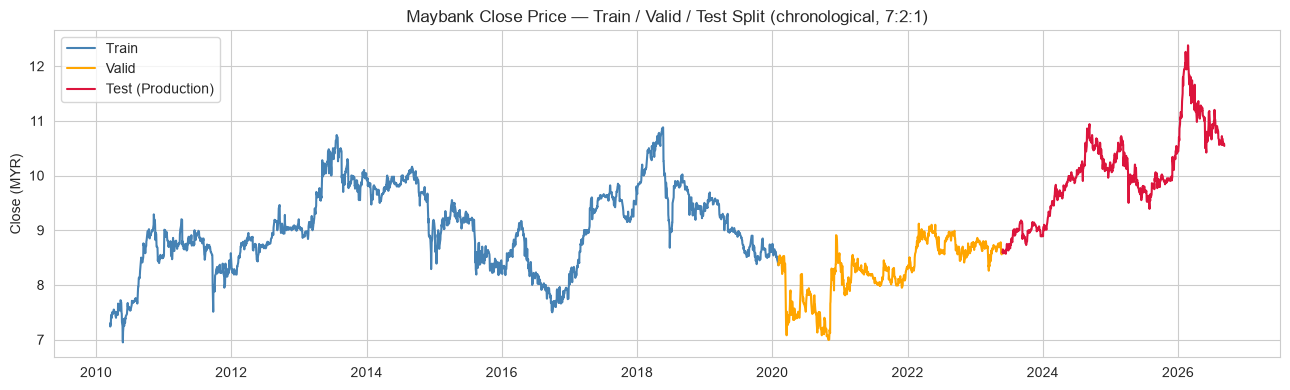

In [36]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    train_df.index,
    maybank_clean.loc[train_df.index, "Close"],
    label="Train",
    color="steelblue",
)
ax.plot(
    valid_df.index,
    maybank_clean.loc[valid_df.index, "Close"],
    label="Valid",
    color="orange",
)
ax.plot(
    test_df.index,
    maybank_clean.loc[test_df.index, "Close"],
    label="Test (Production)",
    color="crimson",
)
ax.set_title("Maybank Close Price — Train / Valid / Test Split (chronological, 7:2:1)")
ax.set_ylabel("Close (MYR)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. XGBoost Hyperparameter Tuning

We tune the `XGBClassifier` with a manual/randomized grid search over the validation set, using:
- `early_stopping_rounds` (fit on train, monitored on valid, stops if valid performance doesn't improve)
- `learning_rate`
- `n_estimators` (upper bound — early stopping finds the actual best number of trees per configuration)
- `max_depth`, `subsample`, `colsample_bytree`, `min_child_weight` for regularization / generalization control

We select the configuration with the **highest validation accuracy**, and record the best number of estimators (boosting rounds) discovered via early stopping.

In [37]:
param_grid = {
    "learning_rate":    [0.02, 0.05],
    "max_depth":        [2, 3],
    "subsample":        [0.7, 0.85],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [5, 15, 30],
    "gamma":            [0.1, 0.5],
}

MAX_ESTIMATORS = 500       # ceiling; early stopping finds optimal tree count
EARLY_STOPPING_ROUNDS = 25

keys, values = zip(*param_grid.items())
all_combos = [dict(zip(keys, v)) for v in product(*values)]
print(f"Total hyperparameter combinations to try: {len(all_combos)}")

Total hyperparameter combinations to try: 96


In [38]:
# Suppress verbose Optuna logging output per trial
optuna.logging.set_verbosity(optuna.logging.WARNING)

MAX_ESTIMATORS = 500
EARLY_STOPPING_ROUNDS = 25


def objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "n_estimators": MAX_ESTIMATORS,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        # --- Search Space ---
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.08),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 35),
        "subsample": trial.suggest_float("subsample", 0.65, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "gamma": trial.suggest_float("gamma", 0.05, 0.8),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.05, 3.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_valid, y_valid)],
        sample_weight_eval_set=[sample_weights_valid],
        verbose=False,
    )

    valid_pred = model.predict(X_valid)
    # Optimize for Validation Macro F1
    return f1_score(y_valid, valid_pred, average="macro", zero_division=0)


print("Running Optuna Bayesian Optimization (50 trials)...")
study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("\n" + "=" * 60)
print(f"OPTUNA BEST VALID MACRO F1: {study.best_value:.4f}")
print("=" * 60)
for k, v in best_params.items():
    print(
        f"  {k:>18}: {v:.4f}"
        if isinstance(v, float)
        else f"  {k:>18}: {v}"
    )



Running Optuna Bayesian Optimization (50 trials)...

OPTUNA BEST VALID MACRO F1: 0.3866
       learning_rate: 0.0426
           max_depth: 3
    min_child_weight: 7
           subsample: 0.8596
    colsample_bytree: 0.6320
               gamma: 0.7758
           reg_alpha: 2.1926
          reg_lambda: 0.6864


In [39]:
# Optuna training Results 
trials_df = study.trials_dataframe()

# Extracting params and validation macro F1
param_cols = [c for c in trials_df.columns if c.startswith("params_")]
display_df = trials_df[["number","value"]+ param_cols].copy()
display_df.rename(columns={"number":"trail", "value":"valid_macro_f1"},inplace=True)
display_df.columns = [c.replace("params_","")for c in display_df.columns]

tuning_results_df = (
    display_df.sort_values("valid_macro_f1",ascending =False).reset_index(drop=True)
)

print(f"Top 10 Optuna Trials out of {len(trials_df)} :")
tuning_results_df.head(10)


Top 10 Optuna Trials out of 50 :


,trail,valid_macro_f1,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample
0,46,0.386623,0.631987,0.775757,0.042617,3,7,2.192554,0.686413,0.859632
1,24,0.385232,0.662519,0.733906,0.025578,3,6,2.183376,0.586618,0.846041
2,41,0.384490,0.644177,0.680901,0.029247,3,6,0.864196,0.841332,0.858668
3,47,0.383521,0.632063,0.768342,0.039551,3,6,1.822865,0.814705,0.859868
4,8,0.380190,0.622365,0.790165,0.033261,3,9,1.180696,0.790107,0.850549
5,48,0.379754,0.648658,0.765378,0.035521,3,9,1.239251,0.790289,0.857008
6,0,0.379600,0.646806,0.166996,0.039345,4,27,0.063424,3.674059,0.799665
7,49,0.378080,0.639005,0.769758,0.038282,3,10,2.601609,0.695364,0.835749
8,45,0.377170,0.623512,0.793289,0.025806,3,5,0.796504,0.748200,0.833803
9,30,0.374666,0.611900,0.724878,0.025923,3,12,0.782599,0.727389,0.845026


### Refit the final model

We refit an `XGBClassifier` using the best hyperparameters, with `n_estimators` fixed to the optimal boosting round count found above (rather than relying on early stopping again), trained on Train and validated against Valid one more time for a clean final artifact.

In [40]:
# --- Refit Final Model with Best Parameters & Find Best Trees ---
final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_estimators=MAX_ESTIMATORS,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    **best_params,
)

final_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_valid, y_valid)],
    sample_weight_eval_set=[sample_weights_valid],
    verbose=False,
)

best_n_estimators = getattr(final_model, "best_iteration", MAX_ESTIMATORS)
print("Final model refit complete.")
print(f"Optimal boosting rounds (trees): {best_n_estimators}")

Final model refit complete.
Optimal boosting rounds (trees): 49


## 5. Baseline Comparison

With 3 classes, a naive baseline that always predicts a fixed class (e.g. always "Buy") is a sense check for whether the model is doing any better than blindly exploiting whichever class happens to dominate. We use the **majority class observed in the training data** (typically "Hold", since large single-day moves that clear the threshold band are relatively rare) as the baseline prediction for every row.

In [41]:
majority_class = int(y_train.mode()[0])
majority_class_name = LABEL_NAMES[majority_class]
print(
    f"Majority class in training data: '{majority_class_name}' ({(y_train == majority_class).mean():.2%} of train rows)"
)

baseline_predictions = np.full(len(y_test), majority_class, dtype=int)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(
    f"\nBaseline (always predict '{majority_class_name}') — Test accuracy: {baseline_accuracy:.4f}"
)

# Also report baseline on train/valid for context
print(
    f"Baseline accuracy on Train: {accuracy_score(y_train, np.full(len(y_train), majority_class, dtype=int)):.4f}"
)
print(
    f"Baseline accuracy on Valid: {accuracy_score(y_valid, np.full(len(y_valid), majority_class, dtype=int)):.4f}"
)

Majority class in training data: 'STILL' (56.48% of train rows)

Baseline (always predict 'STILL') — Test accuracy: 0.5903
Baseline accuracy on Train: 0.5648
Baseline accuracy on Valid: 0.4969


## 6. Full Model Performance Results

Comprehensive evaluation across Train, Valid, and Test sets: accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and feature importance.

In [42]:
# --- Confidence Thresholding Function ---
CONFIDENCE_THRESHOLD = 0.42  # Only trade if model is at least 42% sure (vs 33% random baseline)


def predict_with_confidence(proba_matrix, threshold=CONFIDENCE_THRESHOLD):
    """proba_matrix shape: (N, 3) where:

    col 0 = P(STILL), col 1 = P(UP), col 2 = P(DOWN)
    If P(UP) >= threshold and P(UP) > P(DOWN) -> UP (1)
    If P(DOWN) >= threshold and P(DOWN) > P(UP) -> DOWN (2)
    Otherwise -> STILL (0) (sit out in cash)
    """
    preds = np.zeros(len(proba_matrix), dtype=int)
    p_up = proba_matrix[:, 1]
    p_down = proba_matrix[:, 2]

    up_mask = (p_up >= threshold) & (p_up > p_down)
    down_mask = (p_down >= threshold) & (p_down > p_up)

    preds[up_mask] = 1
    preds[down_mask] = 2
    return preds


# Probabilities for all splits
train_prob = final_model.predict_proba(X_train)
valid_prob = final_model.predict_proba(X_valid)
test_prob = final_model.predict_proba(X_test)

# Apply confidence thresholding
train_pred = predict_with_confidence(train_prob)
valid_pred = predict_with_confidence(valid_prob)
test_pred = predict_with_confidence(test_prob)


# Evaluate
def evaluate(y_true, pred, prob, split_name):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, pred),
        "precision_macro": precision_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(y_true, pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(
            y_true, prob, multi_class="ovr", average="macro"
        ),
    }


# Explicitly store test_metrics for subsequent cells
train_metrics = evaluate(y_train, train_pred, train_prob, "Train")
valid_metrics = evaluate(y_valid, valid_pred, valid_prob, "Valid")
test_metrics = evaluate(y_test, test_pred, test_prob, "Test (Production)")

results_summary = pd.DataFrame([train_metrics, valid_metrics, test_metrics]).set_index("split")

print("=== EVALUATION WITH CONFIDENCE THRESHOLDING ===")
results_summary.round(4)

=== EVALUATION WITH CONFIDENCE THRESHOLDING ===


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr_macro
split,,,,,
Train,0.6391,0.6859,0.4886,0.5095,0.7796
Valid,0.4932,0.4246,0.3912,0.3775,0.5771
Test (Production),0.5990,0.5102,0.4003,0.3918,0.6147


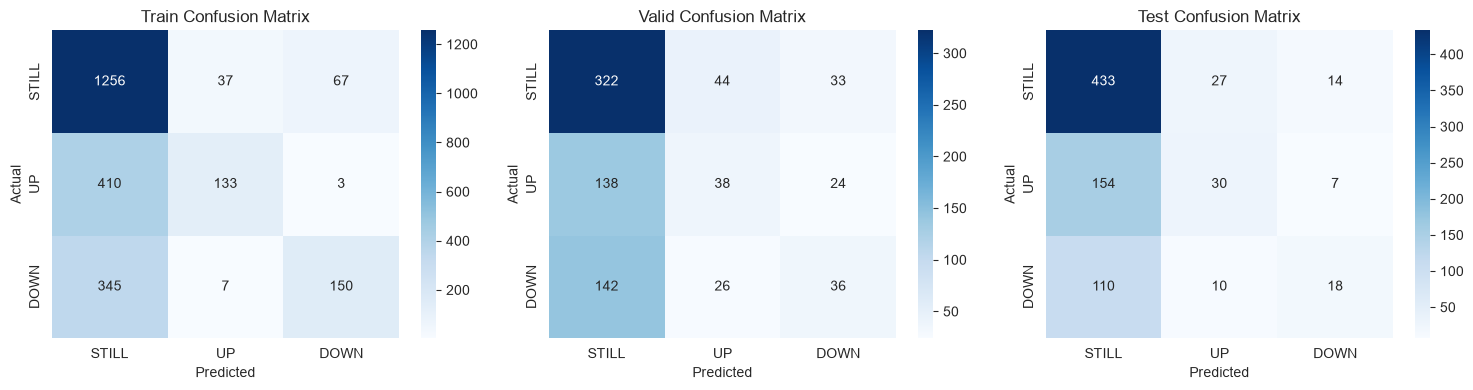

In [43]:
CLASS_LABELS = [0,1,2]
CLASS_NAMES = [LABEL_NAMES[i] for i in CLASS_LABELS]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_true, pred) in zip(
    axes,
    [
        ("Train", y_train, train_pred),
        ("Valid", y_valid, valid_pred),
        ("Test", y_test, test_pred),
    ],
):
    cm = confusion_matrix(y_true, pred, labels=CLASS_LABELS)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [44]:
print("=== TRAIN classification report ===")
print(
    classification_report(
        y_train,
        train_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== VALID classification report ===")
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== TEST (Production) classification report ===")
print(
    classification_report(
        y_test,
        test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

=== TRAIN classification report ===
              precision    recall  f1-score   support

       STILL       0.62      0.92      0.75      1360
          UP       0.75      0.24      0.37       546
        DOWN       0.68      0.30      0.42       502

    accuracy                           0.64      2408
   macro avg       0.69      0.49      0.51      2408
weighted avg       0.67      0.64      0.59      2408

=== VALID classification report ===
              precision    recall  f1-score   support

       STILL       0.53      0.81      0.64       399
          UP       0.35      0.19      0.25       200
        DOWN       0.39      0.18      0.24       204

    accuracy                           0.49       803
   macro avg       0.42      0.39      0.38       803
weighted avg       0.45      0.49      0.44       803

=== TEST (Production) classification report ===
              precision    recall  f1-score   support

       STILL       0.62      0.91      0.74       474
         

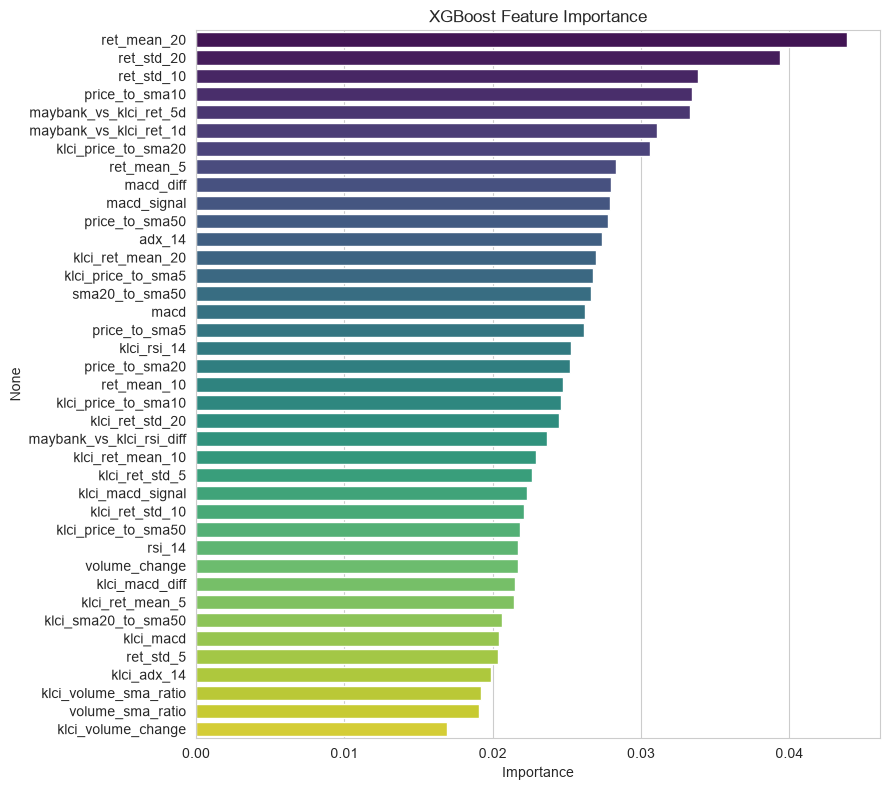


Share of total importance coming from FBM KLCI / relative-to-market features: 49.83%


In [45]:
# Feature importance — which signals (Maybank technicals vs KLCI market-context) matter most
importance = pd.Series(
    final_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

klci_importance_share = importance[
    [c for c in importance.index if c.startswith("klci_") or "vs_klci" in c]
].sum()
print(
    f"\nShare of total importance coming from FBM KLCI / relative-to-market features: {klci_importance_share / importance.sum():.2%}"
)

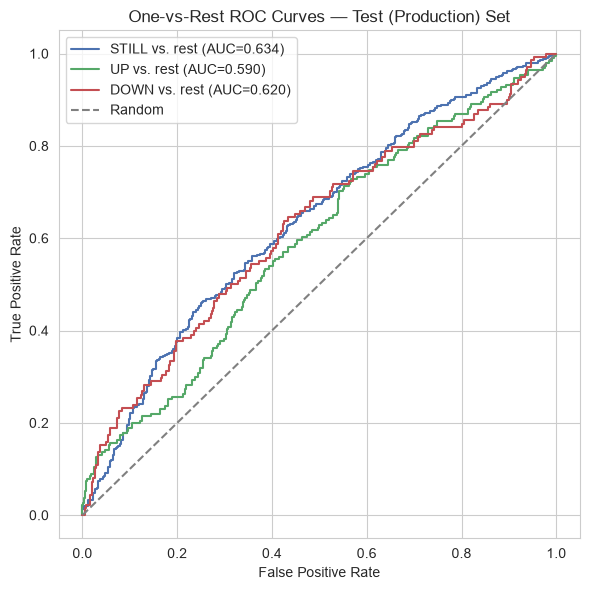

In [46]:
# One-vs-Rest ROC curves (one per class) on the Test (production) set — with 3 classes there is
# no single ROC curve, so we plot each class against "everything else" and report its own AUC.
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=CLASS_LABELS)
colors = ["#4C72B0", "#55A868", "#C44E52"]

plt.figure(figsize=(6, 6))
for i, cls in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], test_prob[:, i])
    plt.plot(
        fpr, tpr, label=f"{LABEL_NAMES[cls]} vs. rest (AUC={auc:.3f})", color=colors[i]
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves — Test (Production) Set")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Test (Production) Score

The Test split (final 10% chronologically) was **never touched during tuning** — this is our best estimate of how the model would perform if deployed "live" going forward. We compare it directly against the majority-class baseline on the *same* Test set.

In [47]:

# --- Production Test Performance Summary ---
print("=" * 55)
print("PRODUCTION (TEST) PERFORMANCE SUMMARY")
print("=" * 55)
print(f"Test period             : {test_df.index.min().date()} -> {test_df.index.max().date()}")
print(f"Number of test days     : {len(y_test)}")
print("-" * 55)
print(f"XGBoost Model Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"Baseline Accuracy       : {baseline_accuracy:.4f}  (always predicts '{majority_class_name}')")
print(f"Improvement over base.  : {test_metrics['accuracy'] - baseline_accuracy:+.4f}")
print("-" * 55)
print(f"Precision (macro)       : {test_metrics['precision_macro']:.4f}")
print(f"Recall (macro)          : {test_metrics['recall_macro']:.4f}")
print(f"F1-score (macro)        : {test_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (OvR macro)     : {test_metrics['roc_auc_ovr_macro']:.4f}")
print("=" * 55)

comparison_df = pd.DataFrame(
    {
        "Model": ["XGBoost (tuned)", f"Baseline (always {majority_class_name})"],
        "Accuracy": [test_metrics["accuracy"], baseline_accuracy],
    }
)
comparison_df

PRODUCTION (TEST) PERFORMANCE SUMMARY
Test period             : 2023-05-29 -> 2026-09-08
Number of test days     : 803
-------------------------------------------------------
XGBoost Model Accuracy  : 0.5990
Baseline Accuracy       : 0.5903  (always predicts 'STILL')
Improvement over base.  : +0.0087
-------------------------------------------------------
Precision (macro)       : 0.5102
Recall (macro)          : 0.4003
F1-score (macro)        : 0.3918
ROC-AUC (OvR macro)     : 0.6147


,Model,Accuracy
0,XGBoost (tuned),0.599004
1,Baseline (always STILL),0.590286


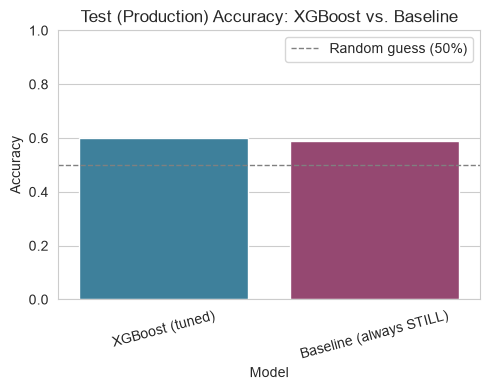

In [48]:
plt.figure(figsize=(5, 4))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette=["#2E86AB", "#A23B72"])
plt.ylim(0, 1)
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1, label="Random guess (50%)")
plt.xticks(rotation=15)
plt.title("Test (Production) Accuracy: XGBoost vs. Baseline")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Mock Trading Simulation (on Test / Production Data)

With a genuine 3-way **Buy / Hold / Sell** signal, the simulation maps directly onto trading actions for each day in the Test period:

- **Buy (1)**  → go **long** for that day (capture the actual next-day return)
- **Sell (2)** → go **short** for that day (capture the *inverse* of the actual next-day return)
- **Hold (0)** → stay in **cash** for that day (0% return)

> Note: modeling "Sell" as a short position is a simplification for comparison purposes. Short-selling on Bursa Malaysia is restricted to approved securities and incurs borrowing costs/margin requirements not modeled here — in a more conservative simulation, "Sell" could instead just mean "exit to cash," which would produce a more cautious (lower-risk, lower-return) version of this same strategy.

We compare three portfolios on the Test set, all starting from the same capital:
- **XGBoost Model strategy** — acts on the tuned model's daily predictions
- **Baseline strategy** — acts on the majority-class baseline's predictions (Section 5)
- **Buy & Hold** — stays invested in Maybank for the entire test period, ignoring any signal

This is a simplified simulation — it ignores transaction costs, slippage, dividends, taxes, and realistic position sizing, and is meant only to illustrate whether the model's signal has directional value, not to be an actual backtested trading system.

In [49]:
# --- Swing Simulation with Broker Fees & Confidence Thresholding ---
BROKER_FEE = 0.001  # 0.10% per trade side
STARTING_CAPITAL = 10_000

daily_actual_return = (
    maybank_clean["Close"].pct_change().shift(-1).loc[test_df.index]
)

sim = pd.DataFrame(
    {
        "actual_return": daily_actual_return,
        "model_signal": test_pred,
        "baseline_signal": baseline_predictions,
    },
    index=test_df.index,
)


def signal_to_position(signal_series):
    return np.select([signal_series == 1, signal_series == 2], [1, -1], default=0)


def compute_net_strategy_returns(signal_series, actual_returns, fee_rate):
    position = pd.Series(signal_to_position(signal_series), index=actual_returns.index)
    gross_return = position * actual_returns

    # Fee charged only when position changes
    prev_position = position.shift(1).fillna(0)
    turnover = (position - prev_position).abs()
    tx_cost = turnover * fee_rate
    net_return = gross_return - tx_cost
    return gross_return, tx_cost, net_return, turnover


(
    sim["model_gross_return"],
    sim["model_fee_cost"],
    sim["model_strategy_return"],
    model_turnover,
) = compute_net_strategy_returns(
    sim["model_signal"], sim["actual_return"], BROKER_FEE
)

(
    sim["baseline_gross_return"],
    sim["baseline_fee_cost"],
    sim["baseline_strategy_return"],
    _,
) = compute_net_strategy_returns(
    sim["baseline_signal"], sim["actual_return"], BROKER_FEE
)

# Buy & Hold
sim["UP_STILL_return"] = sim["actual_return"].copy()
sim.loc[sim.index[0], "UP_STILL_return"] -= BROKER_FEE

sim["model_equity"] = STARTING_CAPITAL * (1 + sim["model_strategy_return"]).cumprod()
sim["baseline_equity"] = (
    STARTING_CAPITAL * (1 + sim["baseline_strategy_return"]).cumprod()
)
sim["UP_STILL_equity"] = STARTING_CAPITAL * (1 + sim["UP_STILL_return"]).cumprod()

sim["model_signal_label"] = sim["model_signal"].map(LABEL_NAMES)

total_trades = int(model_turnover.sum())
print("=== HIGH-CONVICTION SWING SIMULATION ===")
print(f"Confidence Threshold : {CONFIDENCE_THRESHOLD:.0%}")
print(f"Total trades taken   : {total_trades} trades")
print(
    f"Total fees paid      : MYR {sim['model_fee_cost'].sum() * STARTING_CAPITAL:.2f}"
)
print("\nFiltered Signal Distribution:")
print(sim["model_signal_label"].value_counts())
sim.tail()

=== HIGH-CONVICTION SWING SIMULATION ===
Confidence Threshold : 42%
Total trades taken   : 118 trades
Total fees paid      : MYR 1180.00

Filtered Signal Distribution:
model_signal_label
STILL    697
UP        67
DOWN      39
Name: count, dtype: int64


,actual_return,model_signal,baseline_signal,model_gross_return,model_fee_cost,model_strategy_return,baseline_gross_return,baseline_fee_cost,baseline_strategy_return,UP_STILL_return,model_equity,baseline_equity,UP_STILL_equity,model_signal_label
Date,,,,,,,,,,,,,,
2026-09-02,-0.001887,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.001887,12898.022022,10000.0,12290.008300,STILL
2026-09-03,-0.001890,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.001890,12898.022022,10000.0,12266.776346,STILL
2026-09-04,0.001894,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.001894,12898.022022,10000.0,12290.008300,STILL
2026-09-07,-0.003781,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.003781,12898.022022,10000.0,12243.543284,STILL
2026-09-08,-0.007590,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.007590,12898.022022,10000.0,12150.613253,STILL


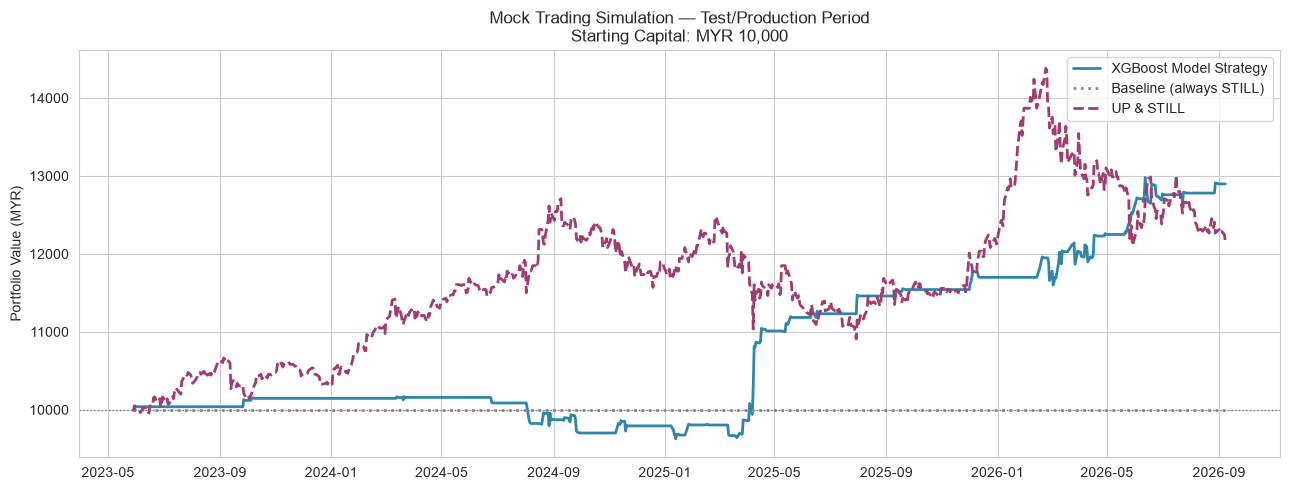

In [50]:
plt.figure(figsize=(13, 5))
plt.plot(
    sim.index,
    sim["model_equity"],
    label="XGBoost Model Strategy",
    color="#2E86AB",
    linewidth=2,
)
plt.plot(
    sim.index,
    sim["baseline_equity"],
    label=f"Baseline (always {majority_class_name})",
    color="#8C8C8C",
    linewidth=2,
    linestyle=":",
)
plt.plot(
    sim.index,
    sim["UP_STILL_equity"],
    label="UP & STILL",
    color="#A23B72",
    linewidth=2,
    linestyle="--",
)
plt.axhline(STARTING_CAPITAL, color="gray", linewidth=1, linestyle=":")
plt.title(
    f"Mock Trading Simulation — Test/Production Period\nStarting Capital: MYR {STARTING_CAPITAL:,}"
)
plt.ylabel("Portfolio Value (MYR)")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
def sim_summary(returns, equity, name):
    total_return = equity.iloc[-1] / STARTING_CAPITAL - 1
    n_days = len(returns)
    ann_factor = 252 / n_days
    cagr = (1 + total_return) ** ann_factor - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252) + 1e-9)
    max_dd = (equity / equity.cummax() - 1).min()
    win_rate = (returns > 0).mean()

    return {
        "Strategy": name,
        "Final Equity (MYR)": round(equity.iloc[-1], 2),
        "Total Return": f"{total_return:.2%}",
        "Annualized Return (CAGR)": f"{cagr:.2%}",
        "Annualized Volatility": f"{vol:.2%}",
        "Sharpe Ratio (rf=0)": round(sharpe, 3),
        "Max Drawdown": f"{max_dd:.2%}",
        "Win Rate (days)": f"{win_rate:.2%}",
    }


sim_results = pd.DataFrame(
    [
        sim_summary(sim["model_strategy_return"], sim["model_equity"], "XGBoost Model"),
        sim_summary(
            sim["baseline_strategy_return"],
            sim["baseline_equity"],
            f"Baseline (always {majority_class_name})",
        ),
        sim_summary(sim["UP_STILL_return"], sim["UP_STILL_equity"], "UP & STILL"),
    ]
).set_index("Strategy")

sim_results

,Final Equity (MYR),Total Return,Annualized Return (CAGR),Annualized Volatility,Sharpe Ratio (rf=0),Max Drawdown,Win Rate (days)
Strategy,,,,,,,
XGBoost Model,12898.02,28.98%,8.31%,6.78%,1.211,-5.31%,7.97%
Baseline (always STILL),10000.00,0.00%,0.00%,0.00%,0.000,0.00%,0.00%
UP & STILL,12150.61,21.51%,6.30%,13.22%,0.528,-15.83%,44.46%


### Interpretation

- If the **XGBoost Model** strategy shows a higher Sharpe ratio / lower drawdown than Buy & Hold and the baseline, that suggests the model's Buy/Hold/Sell signal (partly informed by FBM KLCI market-context features) has some practical trading value beyond raw accuracy.
- Because "Hold" sits out entirely (0% return, 0% risk) and "Sell" actively bets against the stock, this 3-class strategy can behave very differently from a simple always-invested benchmark — check the **signal distribution** printed above to see how often the model actually chose to act versus stay in cash.
- Remember that **accuracy alone doesn't capture magnitude of moves** — a model can be right more often on small moves and wrong on big ones (or vice versa), and this simulation doesn't weight position size by model confidence.
- Always treat this as a **sanity check**, not investment advice — no transaction costs, slippage, dividends, margin/borrowing costs for shorting, or realistic position sizing were modeled, and past performance on this single stock/period is not a guarantee of future results.